# LPT with and without radial RSDs

The same 2LPT realization at a = 1, viewed in real space and redshift space.
The observer is stationary at the box centre: `observer = (0.5, 0.5, 0.5)`
in Cartesian box fractions. Both density fields use the same particle grid
and mass assignment. This is one snapshot, not a lightcone.


In [1]:
from pathlib import Path
import sys

# Allow running from either the repository root or notebooks/.
root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(root / "src"))

import numpy as np
import matplotlib.pyplot as plt

from cobox import Box, GRFSampler, Particles
from colcdm import Cosmology, LinearMatterPowSpec, LPT


/home/prosello/Documents/phd/code/cobox-repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
N, L = 256, 750.0  # grid size and box length [Mpc/h]
a = 1.0
observer = (0.5, 0.5, 0.5)

box = Box(N=N, L=L, D=3)
cosmology = Cosmology.from_preset("planck18")
pk = LinearMatterPowSpec(
    transfer_kind="symbolic_pofk",
    growth_kind="symbolic_pofk",
    cosmology=cosmology,
)
delta0 = GRFSampler(kind="real").sample_from_seed(0, box, pk)


In [19]:
# Build the spatial basis once, then compute both displacements.
basis = LPT(order=2, dealias=True).get_psi_basis(delta0)
psi = basis.get_psi(a, cosmology)
psi_rsd = basis.get_psi_rsd(a, cosmology, observer=observer)

# Each displacement starts from the same original lattice.
lattice = Particles(box)
particles = lattice.displace_from_vector_field(psi, interpolation=None)
particles_rsd = lattice.displace_from_vector_field(psi_rsd, interpolation=None)

delta = particles.deposit(N, bspline_order=2, return_contrast=True)
delta_rsd = particles_rsd.deposit(N, bspline_order=2, return_contrast=True)


Compare a thin slab through the observer. The first two panels share a
colour scale; the third shows the density change caused by RSDs. The cyan
cross marks the observer. Deposition uses the box's periodic boundaries.


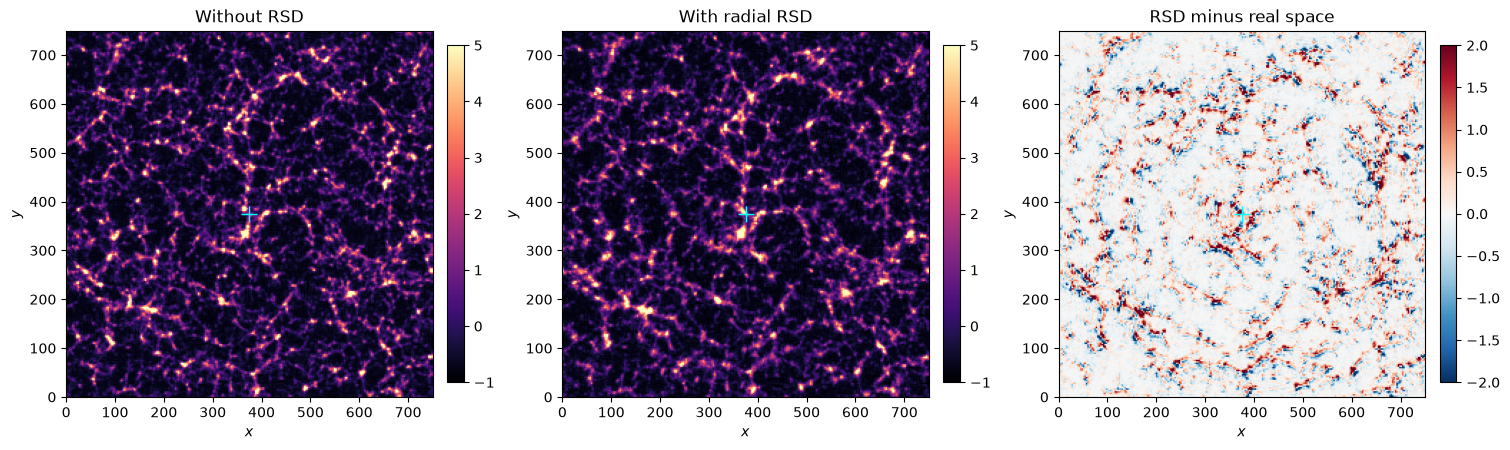

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
view = dict(axis=2, slab=round(observer[2] * N), width=3)

delta.paint(
    ax=axes[0], **view, 
    cmap="magma", vmin=-1, vmax=5, title="Without RSD",
)
delta_rsd.paint(
    ax=axes[1], **view, 
    cmap="magma", vmin=-1, vmax=5, title="With radial RSD",
)
(delta_rsd - delta).paint(
    ax=axes[2], **view, 
    cmap="RdBu_r", vmin=-2, vmax=2, title="RSD minus real space",
)

for ax in axes:
    ax.plot(observer[0] * L, observer[1] * L, "+", color="cyan", ms=12)

plt.show()